In [2]:
# Do not change this cell
import numpy as np
import torch
from torch import nn
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

num_classes = 4
num_features = 2
random_seed = 1

# Create dataset
X, y = make_blobs(n_samples=10000, n_features=num_features, centers=num_classes, 
                  cluster_std=1.5, random_state=random_seed)

# Convert to tensor
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.LongTensor)

# Split dataset into train/test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_seed)

In [3]:
# TODO: you will design your model here
class SimpleModel(nn.Module):
    def __init__(self, input_size, output_size):
        # Initialize nn.Module state
        super(SimpleModel, self).__init__()
        # Define model layers and ReLU activation function
        self.ln1 = nn.Linear(input_size, 32) # input layer
        self.ln2 = nn.Linear(32, 16) # hidden layer
        self.ln3 = nn.Linear(16, output_size) # output layer
        self.relu = nn.ReLU() # ReLU activation 

    def forward(self, x):
        # Forward pass using ReLU activation function
        x = self.relu(self.ln1(x))
        x = self.relu(self.ln2(x))
        x = self.ln3(x)
        return x

In [4]:
def train_step(model, X_train, y_train, loss_fn, optimizer, device):
    # One epoch of training:
    # Set model to training mode and initialize train_loss, correct_predictions, and total_samples
    model.train()
    train_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    # Move data to device (cpu or gpu)
    X_train = X_train.to(device)
    y_train = y_train.to(device)

    # Combine training data into a TensorDataset and create DataLoader for batching and shuffling
    train_dataset = torch.utils.data.TensorDataset(X_train, y_train)
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)

    # Iterate through data in each batch
    for x, y in train_loader:
        # Move batch data to device
        x = x.to(device)
        y = y.to(device)

        # Forward pass
        y_pred = model(x)
        loss = loss_fn(y_pred, y)

        # Zero gradients, perform a backward pass, and update the weights
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Accumulate loss (scaled by batch size)
        train_loss += loss.item() * x.size(0)
        # Get predictions (class indices)
        _, predicted = torch.max(y_pred.data, 1)
        # Update total_samples and correct_predictions for accuracy calculation
        total_samples += y.size(0)
        correct_predictions += (predicted == y).sum().item()

    # Calculate average loss and accuracy
    train_loss /= total_samples
    train_accuracy = (correct_predictions / total_samples) * 100

    return train_loss, train_accuracy

In [5]:
def evaluation_step(model, X_test, y_test, loss_fn, device):
    # Set model to eval mode and initialize test_loss, correct_predictions, and total_samples
    model.eval()
    test_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    # Move data to device (cpu or gpu)
    X_test = X_test.to(device)
    y_test = y_test.to(device)

    # Combine test data into a TensorDataset and create DataLoader for batching and shuffling
    test_dataset = torch.utils.data.TensorDataset(X_test, y_test)
    test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=True)

    # Disable gradient calculation for evaluation
    with torch.no_grad():
        # Iterate through data in each batch
        for x, y in test_loader:
            # Move batch data to device
            x = x.to(device)
            y = y.to(device)

            # Forward pass
            y_pred = model(x)
            loss = loss_fn(y_pred, y)

            # Accumulate loss (scaled by batch size)
            test_loss += loss.item() * x.size(0)
            # Get predictions (class indices)
            _, predicted = torch.max(y_pred.data, 1)
            # Update total_samples and correct_predictions for accuracy calculation
            total_samples += y.size(0)
            correct_predictions += (predicted == y).sum().item()

    # Calculate average loss and accuracy
    test_loss /= total_samples
    test_accuracy = (correct_predictions / total_samples) * 100

    return test_loss, test_accuracy

In [10]:
def train_simple_model(X_train, y_train, X_test, y_test, random_seed):
    # Make device
    device = "cpu" 
    if torch.cuda.is_available(): 
        device = "cuda"
    else:
        if torch.backends.mps.is_available():
            device = "mps" 
    
    torch.manual_seed(random_seed) # do not change this

    # Get input and output sizes from data
    input_size = X_train.shape[1]
    output_size = len(torch.unique(y_train))
    
    # Create model and move to device
    model = SimpleModel(input_size, output_size)
    model = model.to(device)

    # Define loss function (Cross-Entropy) and optimizer
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

    # Define number of epochs and track train/test losses and accuracies
    num_epochs = 40
    train_losses = []
    train_accuracies = []
    test_losses = []
    test_accuracies = []

    # Iterate through epochs, apply 'train_step' and 'evaluation_step', and store losses/accuracies
    for epoch in range(num_epochs):
        train_loss, train_accuracy = train_step(model, X_train, y_train, loss_fn, optimizer, device)
        test_loss, test_accuracy = evaluation_step(model, X_test, y_test, loss_fn, device)
        
        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)
        test_losses.append(test_loss)
        test_accuracies.append(test_accuracy)
        
        # Print train/test losses and accuracies after each epoch
        print(f"Epoch {epoch+1}/{num_epochs}: Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.2f}%, Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.2f}%")

    return model, train_losses, train_accuracies, test_losses, test_accuracies

In [12]:
# TODO: plot accuracy curves
def plot_accuracy_performance(train_accuracies, test_accuracies):
    # Epochs start at 1
    epochs = range(1, len(train_accuracies) + 1)

    # Plot curves
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, train_accuracies, label='training accuracy', color='red')
    plt.plot(epochs, test_accuracies, label='test accuracy', color='blue')

    plt.title('Accuracy Curves')
    plt.xlabel('# of Epochs')
    plt.ylabel('Prediction Accuracy (%)')
    plt.legend()
    plt.grid(False)

In [14]:
# TODO: plot loss curves
def plot_loss_performance(train_losses, test_losses):
    # Epochs start at 1
    epochs = range(1, len(train_losses) + 1)

    # Plot curves
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, train_losses, label='train loss', color='green')
    plt.plot(epochs, test_losses, label='test loss', color='orange')

    plt.title('Loss Curves (Cross Entropy Loss)')
    plt.xlabel('# of Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(False)

In [16]:
# TODO: plot decision boundary
# import ListedColormap from matplotlib.colors for decsion boundary plot
from matplotlib.colors import ListedColormap
def plot_decision_boundary(model, X_train, y_train):
    # Set model to eval mode
    model.eval()
    # Get device model is on (cpu or gpu)
    device = next(model.parameters()).device

    # Meshgrid of points covering decision space
    # Find minimum and maximum values for each feature in the training data
    x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
    y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
    # Create meshgrid using numpy.meshgrid
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),  # Create x-coordinates of points
                         np.arange(y_min, y_max, 0.01))  # Create y-coordinates of points

    # Convert meshgrid points to tensors and move to device / combine x and y coordinates into single array and flatten
    grid_points = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32).to(device)

    # Make predictions on the meshgrid (gradient calculation disabled)
    with torch.no_grad():
        Z = model(grid_points)
        _, Z = torch.max(Z, 1) # Get the predicted class labels
        Z = Z.cpu().numpy().reshape(xx.shape) # Move predictions back to CPU and reshape to match meshgrid

    # Colormap
    # light colors for shaded regions
    cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF', '#FFFFAA'])  # Red, Green, Blue, Yellow 
    # bold colors for data points
    cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF', '#FFFF00'])  # Red, Green, Blue, Yellow 

    # Plot decision boundary
    plt.contourf(xx, yy, Z, alpha=0.4, cmap=cmap_light)  # Fill regions with colors based on the predictions
    plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=cmap_bold, edgecolors='k', s=20) # Scatter plot of the training data points

    plt.title("Decision Boundary with Training Set")

    # Set axis limits
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

In [18]:
# Do not change this cell
model, train_losses, train_accuracies, test_losses, test_accuracies\
    = train_simple_model(X_train, y_train, X_test, y_test, random_seed)

Epoch 1/40: Train Loss: 1.3124, Train Accuracy: 37.51%, Test Loss: 1.2286, Test Accuracy: 48.65%
Epoch 2/40: Train Loss: 1.1749, Train Accuracy: 46.81%, Test Loss: 1.1093, Test Accuracy: 48.10%
Epoch 3/40: Train Loss: 1.0620, Train Accuracy: 54.31%, Test Loss: 0.9955, Test Accuracy: 66.90%
Epoch 4/40: Train Loss: 0.9514, Train Accuracy: 68.09%, Test Loss: 0.8847, Test Accuracy: 71.75%
Epoch 5/40: Train Loss: 0.8446, Train Accuracy: 71.15%, Test Loss: 0.7809, Test Accuracy: 73.40%
Epoch 6/40: Train Loss: 0.7489, Train Accuracy: 72.36%, Test Loss: 0.6930, Test Accuracy: 73.90%
Epoch 7/40: Train Loss: 0.6715, Train Accuracy: 73.67%, Test Loss: 0.6257, Test Accuracy: 75.60%
Epoch 8/40: Train Loss: 0.6134, Train Accuracy: 75.28%, Test Loss: 0.5764, Test Accuracy: 76.00%
Epoch 9/40: Train Loss: 0.5713, Train Accuracy: 75.66%, Test Loss: 0.5417, Test Accuracy: 77.20%
Epoch 10/40: Train Loss: 0.5408, Train Accuracy: 76.28%, Test Loss: 0.5150, Test Accuracy: 77.60%
Epoch 11/40: Train Loss: 0.51

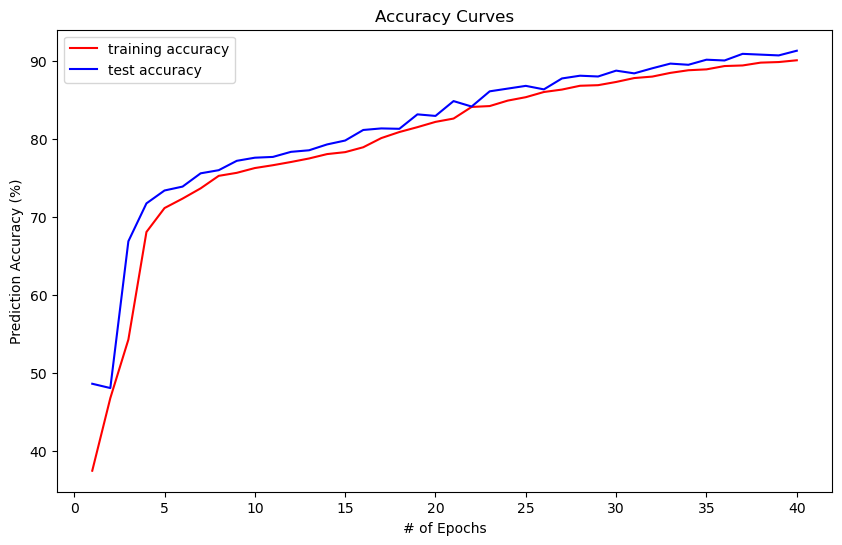

In [20]:
# Do not change this cell
plot_accuracy_performance(train_accuracies, test_accuracies)

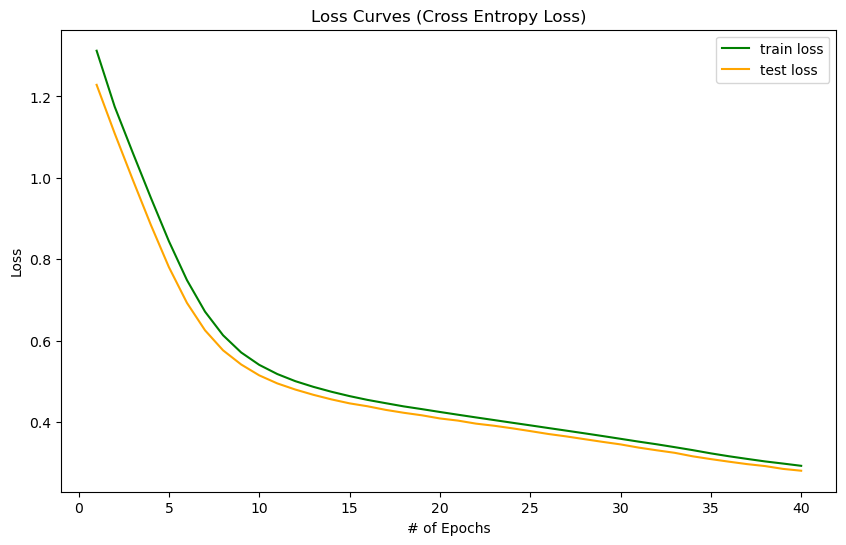

In [22]:
# Do not change this cell
plot_loss_performance(train_losses, test_losses)

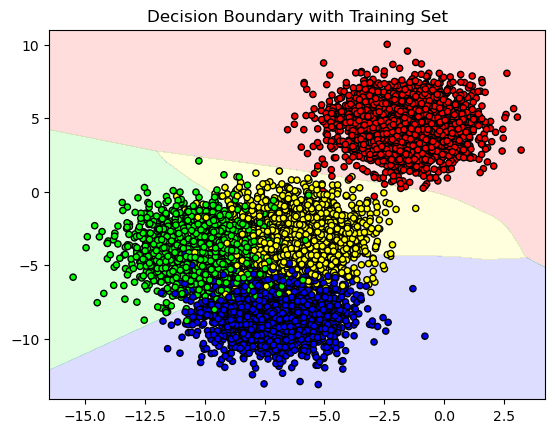

In [24]:
# Do not change this cell
plot_decision_boundary(model, X_train, y_train)